### Verify Active Python Environment

This cell prints the path of the Python interpreter currently running the notebook to install the OSMnx package 

In [1]:
import sys
print(sys.executable)

/Users/saanvikakde/FURI_SP26/venv/bin/python


In [2]:
#Using sys.executable ensures correct virtual environment installation
!{sys.executable} -m pip install osmnx


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Users/saanvikakde/FURI_SP26/venv/bin/python -m pip install --upgrade pip


### Import OSMnx and Verify Installation

This cell imports the OSMnx and GeoPandas libraries required for extracting and managing OpenStreetMap spatial data

Printing the OSMnx version confirms that the package was installed correctly and ensures compatibility with the current API (OSMnx v2.x)

Verifying the library version helps prevent errors caused by outdated function names or syntax differences.

In [2]:
import osmnx as ox
import geopandas as gpd

print("OSMnx version:", ox.__version__)

OSMnx version: 2.0.7


### Load Study Area Boundary and Reproject for OpenStreetMap Query

This cell loads the Maricopa County boundary GeoJSON file into a GeoDataFrame

Because OpenStreetMap queries require geographic coordinates (latitude/longitude) the boundary is reprojected to EPSG:4326 (WGS84)

Reprojecting ensures compatibility with the Overpass API used by OSMnx for extracting greenspace features

<Axes: >

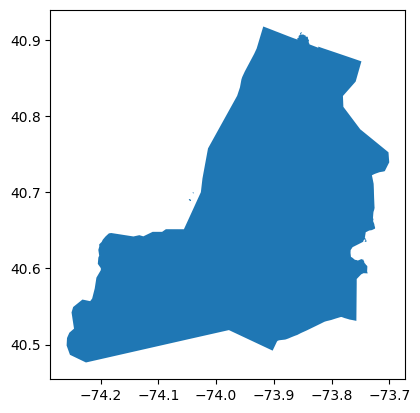

In [3]:
nyc = ox.geocode_to_gdf("New York City, New York, USA")

nyc.plot()


<Axes: >

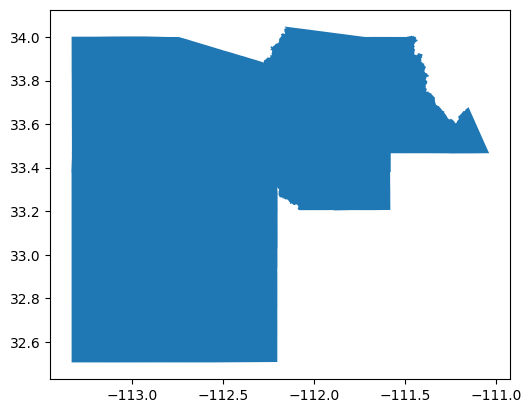

In [5]:
mc = ox.geocode_to_gdf("Maricopa County, Arizona, USA")

mc.plot()


<Axes: >

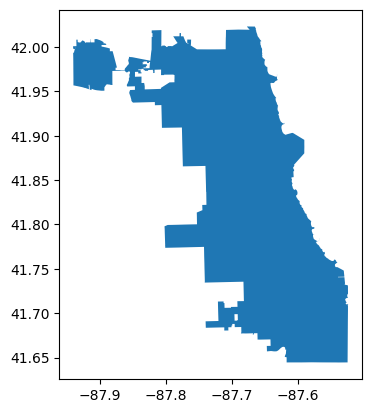

In [13]:
ch = ox.geocode_to_gdf("Chicago, illinois, USA")

ch.plot()

### Extract Greenspace from OpenStreetMap

This cell defines OpenStreetMap (OSM) tag filters and queries greenspace features within the Maricopa County boundary.

The `tags` dictionary specifies the types of natural and recreational areas to extract including:
- Parks
- Gardens
- Recreational grounds
- Grassy land
- Wooded areas

Using `ox.features_from_polygon()`, OSMnx queries the Overpass API to retrieve all features matching these tags within the study area

The result is a GeoDataFrame containing greenspace polygons and associated OSM attributes

In [8]:
tags = {
    "leisure": ["park", "garden"],
    "landuse": ["grass", "recreation_ground"],
    "natural": ["wood"]
}

greenspace_nyc = ox.features_from_polygon(
    nyc.geometry.iloc[0],
    tags
)

greenspace_nyc.head()


geometry ele gnis:feature_id leisure  \
element id                                                                  
node    357545993  POINT (-73.91403 40.87316)  17          942830    park   
        357573219  POINT (-74.17153 40.59649)   7          958459    park   
        357599530   POINT (-73.8229 40.84911)   5          974835    park   
        357607736  POINT (-73.90236 40.88927)  23         2042056    park   
        357607739  POINT (-73.90208 40.88954)  28         2042057    park   

                                    name   wikidata name:etymology:wikidata  \
element id                                                                    
node    357545993            Baker Field  Q34804359                     NaN   
        357573219   New Springville Park  Q49531247                     NaN   
        357599530  Rice Memorial Stadium        NaN                 Q473770   
        357607736        Lower Forecourt  Q49519855                     NaN   
        357607739        Upper Forecourt  Q34867453                     NaN   

                  heritage heritage:operator heritage:website  ... name:de  \
element id                                                     ...           
node    357545993      NaN               NaN              NaN  ...     NaN   
        357573219      NaN               NaN              NaN  ...     NaN   
        357599530      NaN               NaN              NaN  ...     NaN   
        357607736      NaN               NaN              NaN  ...     NaN   
        357607739      NaN               NaN              NaN  ...     NaN   

                  name:pt building:colour building:material linear  \
element id                                                           
node    357545993     NaN             NaN               NaN    NaN   
        357573219     NaN             NaN               NaN    NaN   
        357599530     NaN             NaN               NaN    NaN   
        357607736     NaN             NaN               NaN    NaN   
        357607739     NaN             NaN               NaN    NaN   

                  old_railway_operator roof:material roof:shape protect_class  \
element id                                                                      
node    357545993                  NaN           NaN        NaN           NaN   
        357573219                  NaN           NaN        NaN           NaN   
        357599530                  NaN           NaN        NaN           NaN   
        357607736                  NaN           NaN        NaN           NaN   
        357607739                  NaN           NaN        NaN           NaN   

                  protected  
element id                   
node    357545993       NaN  
        357573219       NaN  
        357599530       NaN  
        357607736       NaN  
        357607739       NaN  

[5 rows x 237 columns]

In [9]:
tags = {
    "leisure": ["park", "garden"],
    "landuse": ["grass", "recreation_ground"],
    "natural": ["wood"]
}

greenspace_mc = ox.features_from_polygon(
    mc.geometry.iloc[0],
    tags
)

greenspace_mc.head()


/Users/saanvikakde/FURI_SP26/venv/lib/python3.14/site-packages/osmnx/_overpass.py:271: UserWarning: This area is 11 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


geometry  ele gnis:feature_id leisure  \
element id                                                                    
node    359241744   POINT (-112.7735 33.24865)  231             402    park   
        359242538  POINT (-112.03792 33.44116)  336            1254    park   
        359243879  POINT (-112.38356 33.37272)  315            2508    park   
        359249716   POINT (-111.8957 33.57365)  412            9196    park   
        359249858  POINT (-112.04765 33.33505)  708            9383    park   

                                              name   wikidata addr:state golf  \
element id                                                                      
node    359241744    Arlington State Wildlife Area        NaN        NaN  NaN   
        359242538                      Berney Park  Q49474501        NaN  NaN   
        359243879  Casey Abbott Semi-Regional Park  Q49477174         AZ  NaN   
        359249716                    Paradise Park  Q49537521        NaN  NaN   
        359249858      Phoenix South Mountain Park  Q49542180        NaN  NaN   

                  landuse natural  ... level toilets golf:course  \
element id                         ...                             
node    359241744     NaN     NaN  ...   NaN     NaN         NaN   
        359242538     NaN     NaN  ...   NaN     NaN         NaN   
        359243879     NaN     NaN  ...   NaN     NaN         NaN   
        359249716     NaN     NaN  ...   NaN     NaN         NaN   
        359249858     NaN     NaN  ...   NaN     NaN         NaN   

                  construction:amenity  tee type boundary ownership  \
element id                                                            
node    359241744                  NaN  NaN  NaN      NaN       NaN   
        359242538                  NaN  NaN  NaN      NaN       NaN   
        359243879                  NaN  NaN  NaN      NaN       NaN   
        359249716                  NaN  NaN  NaN      NaN       NaN   
        359249858                  NaN  NaN  NaN      NaN       NaN   

                  not:operator:wikidata golf:par  
element id                                        
node    359241744                   NaN      NaN  
        359242538                   NaN      NaN  
        359243879                   NaN      NaN  
        359249716                   NaN      NaN  
        359249858                   NaN      NaN  

[5 rows x 105 columns]

In [25]:
tags = {
    "leisure": ["park", "garden"],
    "landuse": ["grass", "recreation_ground"],
    "natural": ["wood"]
}

greenspace_ch = ox.features_from_polygon(
    ch.geometry.iloc[0],
    tags
)

greenspace_ch.head()

geometry  ele gnis:feature_id leisure  \
element id                                                                    
node    354097497   POINT (-87.68254 41.87258)  181          405519    park   
        2274053293  POINT (-87.74992 41.95311)  NaN             NaN    park   
        3993096535  POINT (-87.67874 41.99584)  NaN             NaN    park   
        5157207475  POINT (-87.71226 41.88875)  NaN             NaN  garden   
        8980777459  POINT (-87.71771 41.88601)  NaN             NaN  garden   

                                    name   wikidata type addr:city  \
element id                                                           
node    354097497          Campbell Park  Q34845956  NaN       NaN   
        2274053293  Six Corner's Parklet        NaN  NaN       NaN   
        3993096535            McGee Park        NaN  NaN       NaN   
        5157207475  Garfield Produce Co.        NaN  NaN   Chicago   
        8980777459    Sugar from the Sun        NaN  NaN       NaN   

                   addr:housenumber addr:postcode  ... charge min_height  \
element id                                         ...                     
node    354097497               NaN           NaN  ...    NaN        NaN   
        2274053293              NaN           NaN  ...    NaN        NaN   
        3993096535              NaN           NaN  ...    NaN        NaN   
        5157207475              401         60624  ...    NaN        NaN   
        8980777459              NaN           NaN  ...    NaN        NaN   

                   verge grass heritage heritage:operator protect_class  \
element id                                                                
node    354097497    NaN   NaN      NaN               NaN           NaN   
        2274053293   NaN   NaN      NaN               NaN           NaN   
        3993096535   NaN   NaN      NaN               NaN           NaN   
        5157207475   NaN   NaN      NaN               NaN           NaN   
        8980777459   NaN   NaN      NaN               NaN           NaN   

                   protected protection_title grassland  
element id                                               
node    354097497        NaN              NaN       NaN  
        2274053293       NaN              NaN       NaN  
        3993096535       NaN              NaN       NaN  
        5157207475       NaN              NaN       NaN  
        8980777459       NaN              NaN       NaN  

[5 rows x 108 columns]

### Clean, Reproject, and Save Greenspace Dataset

This cell performs final preprocessing steps on the OpenStreetMap greenspace data:

1. Removes any features with null geometry
2. Reprojects the dataset to match the study boundary CRS
3. Exports the cleaned dataset as a GeoJSON file for future use

Saving the file ensures reproducibility and avoids repeated API calls to OpenStreetMap in subsequent analyses

In [10]:
greenspace_nyc = greenspace_nyc.to_crs(epsg=4326)

greenspace_nyc.to_file(
    "../data/raw/greenspace/nyc_greenspace.geojson",
    driver="GeoJSON"
)

print("Saved NYC greenspace file.")


Saved NYC greenspace file.


In [28]:
greenspace_ch = greenspace_ch.to_crs(epsg=4326)

greenspace_ch.to_file(
    "../data/raw/greenspace/chicago_greenspace.geojson",
    driver="GeoJSON"
)

print("Saved Chicago greenspace file.")

Saved Chicago greenspace file.


In [12]:
greenspace_mc = greenspace_mc.to_crs(epsg=4326)

greenspace_mc.to_file(
    "../data/raw/greenspace/maricopa_greenspace.geojson",
    driver="GeoJSON"
)

print("Saved Maricopa County greenspace file.")


Saved Maricopa County greenspace file.


In [23]:
!ls ../data/raw/greenspace


chicago_greenspace.geojson  nyc_greenspace.geojson
maricopa_greenspace.geojson
